# EL DATASET ES breast-cancer-wisconsin.data

## 1. Contexto General

El conjunto de datos Breast Cancer Wisconsin (Original) es uno de los datasets más utilizados en el aprendizaje automático para tareas de clasificación binaria. Fue recolectado por el Dr. William H. Wolberg de la Universidad de Wisconsin y consiste en muestras de tejido obtenidas mediante aspiración con aguja fina. El objetivo principal es determinar si un tumor es Benigno o Maligno basándose en diversas características celulares medidas en una escala del 1 al 10.

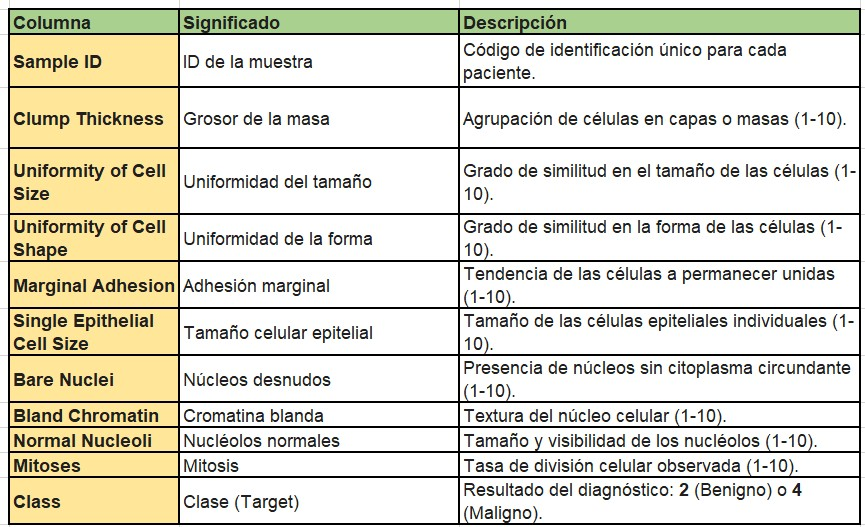

In [ ]:
import pandas as pd
import numpy as np

# 1. Carga del dataset
# Definimos los nombres de las columnas basados en la documentación
columns = [
    "ID", "Clump_Thickness", "Uniformity_Cell_Size", "Uniformity_Cell_Shape",
    "Marginal_Adhesion", "Single_Epithelial_Size", "Bare_Nuclei",
    "Bland_Chromatin", "Normal_Nucleoli", "Mitoses", "Class"
]

# Cargamos el archivo (asumiendo que se llama breast-cancer-wisconsin.data)
df = pd.read_csv('breast-cancer-wisconsin.data', names=columns)

# 2. Preprocesamiento de texto y valores faltantes
# Reemplazamos '?' por NaN en la columna 'Bare_Nuclei'
df['Bare_Nuclei'] = df['Bare_Nuclei'].replace('?', np.nan)

# Convertimos a numérico (esto es necesario porque los '?' forzaron el tipo a string)
df['Bare_Nuclei'] = pd.to_numeric(df['Bare_Nuclei'])

# Imputamos los valores faltantes con la mediana
df['Bare_Nuclei'] = df['Bare_Nuclei'].fillna(df['Bare_Nuclei'].median())

# Transformamos la clase: 2 -> 0 (Benigno), 4 -> 1 (Maligno)
df['Class'] = df['Class'].replace({2: 0, 4: 1})

# Eliminamos la columna ID ya que no aporta valor predictivo
X = df.drop(['ID', 'Class'], axis=1).values
y = df['Class'].values

# 3. Definición de la función de normalización solicitada
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    # Calculamos la media y desviación estándar por columna (axis=0)
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    # Aplicamos la fórmula de normalización (Z-score)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

# 4. Aplicación de la normalización
X_ready, mu, sigma = featureNormalize(X)

print("Dataset preparado con éxito.")
print(f"Forma del set de características: {X_ready.shape}")
print(f"Media de la primera característica post-normalización: {np.mean(X_ready[:,0]):.4f}")